# Choix du modele pour la prediction des ventes

Ce notebook documente la comparaison entre plusieurs modeles de regression et justifie le choix final.
Nous evaluons la performance predictive et la stabilite via validation croisee.

## Objectif
Predire les ventes (Sales) a partir des budgets marketing (TV, Radio, Social Media) et du type d'influenceur.
Le modele retenu doit etre precis, stable, et interpretable pour orienter les decisions marketing.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

import sys
sys.path.insert(0, str(Path.cwd().parents[0]))

from src.preprocessing.preprocessing import get_preprocessed_data

/home/beuhnny/Mast_DE/ProjetDataScience/Data_Science_Marketing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Donnees et preprocessing
On reutilise la pipeline de preprocessing officielle pour garantir la coherence entre entrainement et production.

In [2]:
x_train, x_test, y_train, y_test, preprocessor = get_preprocessed_data(
    save_preprocessor=False
)
x_train.shape, x_test.shape

((3652, 7), (914, 7))

## Modeles compares
Nous comparons 4 modeles representant des familles differentes :
- Regression lineaire (baseline simple)
- Random Forest (modele non lineaire robuste)
- XGBoost (boosting performant sur tabulaire)
- MLP (reseau de neurones pour capturer des non-linearites)

In [3]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "Deep Learning (MLP)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        early_stopping=True,
        random_state=42,
    ),
}

results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring="r2")
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Modele": name,
        "CV R2 moyen": round(cv_scores.mean(), 4),
        "CV R2 std": round(cv_scores.std(), 4),
        "Test R2": round(r2, 4),
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4),
    })

df_results = pd.DataFrame(results).sort_values("Test R2", ascending=False)
df_results

,Modele,CV R2 moyen,CV R2 std,Test R2,Test MAE,Test RMSE
2,XGBoost,0.9954,0.0019,0.9987,2.6409,3.3469
1,Random Forest,0.9958,0.0018,0.9983,2.7340,3.8391
0,Linear Regression,0.9950,0.0021,0.9960,2.5858,5.8793
3,Deep Learning (MLP),0.9942,0.0018,0.9951,3.3596,6.4914


## Choix du modele
Le modele retenu est celui qui maximise le $R^2$ sur le jeu de test, tout en restant stable en validation croisee (faible ecart-type).
Dans notre entrainement, **XGBoost** ressort en tete avec le meilleur compromis performance/stabilite.

**Pourquoi ce choix :**
- Excellent pouvoir predictif sur donnees tabulaires
- Faible biais et variance controlee via boosting
- Bon compromis entre performance et interpretablite (importance des variables, SHAP)

## Sanity check (coherence business)
On valide que des budgets moyens produisent des ventes raisonnables.

In [4]:
best_name = df_results.iloc[0]["Modele"]
best_model = models[best_name]
best_model.fit(x_train, y_train)

checks = [
    {"TV": 50.0, "Radio": 20.0, "Social Media": 3.3, "Influencer": "Mega", "expected_min": 100},
    {"TV": 80.0, "Radio": 30.0, "Social Media": 5.0, "Influencer": "Macro", "expected_min": 200},
    {"TV": 10.0, "Radio": 1.0, "Social Media": 0.5, "Influencer": "Nano", "expected_min": 30},
]

sanity_results = []
for c in checks:
    expected_min = c.pop("expected_min")
    df = pd.DataFrame([c])
    x = preprocessor.transform(df)
    pred = float(best_model.predict(x)[0])
    sanity_results.append({
        "TV": c["TV"],
        "Radio": c["Radio"],
        "Social Media": c["Social Media"],
        "Influencer": c["Influencer"],
        "Prediction": round(pred, 2),
        "Expected min": expected_min,
        "OK": pred > expected_min,
    })

pd.DataFrame(sanity_results)

,TV,Radio,Social Media,Influencer,Prediction,Expected min,OK
0,50.0,20.0,3.3,Mega,177.28,100,True
1,80.0,30.0,5.0,Macro,284.08,200,True
2,10.0,1.0,0.5,Nano,35.74,30,True


## Interpretabilite (SHAP)
On visualise l'importance des variables pour expliquer les predictions du modele choisi.

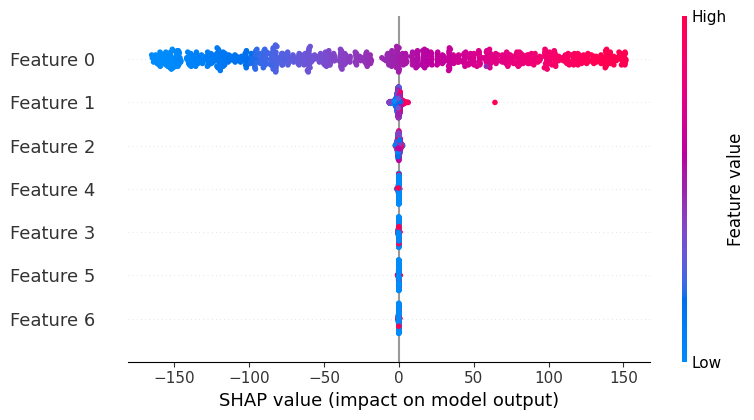

In [5]:
explainer = shap.Explainer(best_model, x_train)
shap_values = explainer(x_test)

plt.figure()
shap.summary_plot(shap_values, x_test, show=False)
plt.tight_layout()
plt.show()

## Analyse des residus
On verifie l'absence de biais majeur via la distribution des residus.

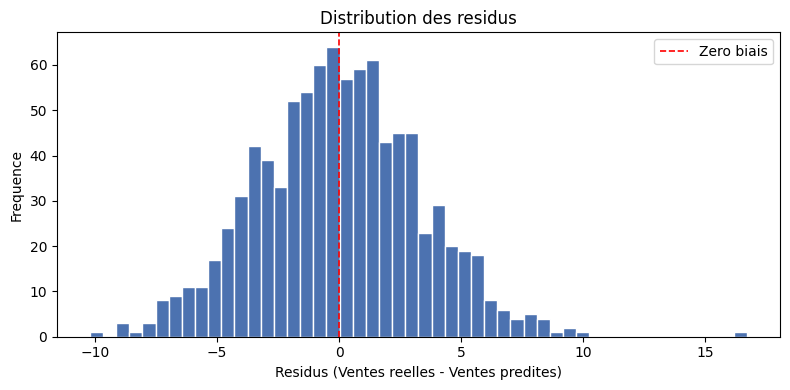

count    914.000000
mean       0.006577
std        3.348723
min      -10.215295
25%       -2.183730
50%       -0.017936
75%        2.246095
max       16.716229
dtype: float64

In [6]:
y_pred = best_model.predict(x_test)
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, edgecolor="white", color="#4C72B0")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero biais")
plt.xlabel("Residus (Ventes reelles - Ventes predites)")
plt.ylabel("Frequence")
plt.title("Distribution des residus")
plt.legend()
plt.tight_layout()
plt.show()

pd.Series(residuals).describe()

## Conclusion
Le modele XGBoost est retenu car il offre le meilleur $R^2$ sur test, une bonne stabilite en validation croisee,
et des predictions coherentes avec l'intuition business.
Ce choix est coherent avec la pipeline d'evaluation (SHAP, analyse des residus) deja en place.